# Minimax Algorithm (with and without Alpha-beta pruning)

## Tic Tac Toe

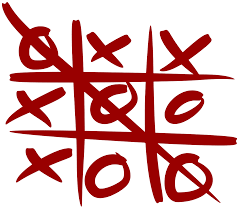

In [6]:
import numpy as np

In [7]:
board = np.array([[" ", " ", "x"],
                 [" ", "x", " "],
                 ["x", " ", " "]])

#### Printing board

In [8]:
def print_tt_board(board):
    print("-------------")
    for row in board:
        for i in row:
            print("|", i, end = " ")
        print("|\n-------------")

print_tt_board(board)

-------------
|   |   | x |
-------------
|   | x |   |
-------------
| x |   |   |
-------------


### Function to find winner

In [9]:
def find_winner(board):
    # Checks rows and columns
    for i in range(3):
        if "xxx" == "".join(list(board[:, i])) or "xxx" == "".join(list(board[i])):
            return -1
        if "ooo" == "".join(list(board[:, i])) or "ooo" == "".join(list(board[i])):
            return 1
    
    # Checks diagonals
    if "xxx" == "".join(list(board[[2,1,0],[0,1,2]])) or "xxx" == "".join(list(board.diagonal())):
        return -1
    if "ooo" == "".join(list(board[[2,1,0],[0,1,2]])) or "ooo" == "".join(list(board.diagonal())):
        return 1
    
    if np.count_nonzero(board == " ") == 0:
        return "Game Ended"
    return 0

test = np.array([["x","x","o"],
                ["x","o","o"],
                ["x","o","x"]])
find_winner(test)

-1

### Regular Minimax Algorithm

In [10]:
def minimax(board, turn, depth):
    winner = find_winner(board)
    if winner == 1 or winner == -1:
        return winner
    
    if depth == 0:
        return 0
    
    if turn:
        best_score = -float("inf")
        best_row, best_col = None, None
        for row in range(3):
            for col in range(3):
                if board[row][col] == " ":
                    board[row][col] = "o"
                    score = minimax(board, False, depth - 1)
                    
                    if type(score) is tuple:
                        score = score[0]
                    board[row][col] = " "
                    
                    if score > best_score:
                        best_score = score
                        best_row, best_col = row, col
                    
        return best_score, best_row, best_col
    else:
        best_score = float("inf")
        for row in range(3):
            for col in range(3):
                if board[row][col] == " ":
                    board[row][col] = "x"
                    score = minimax(board, True, depth - 1)
                    board[row][col] = " "
                    
                    if type(score) is tuple:
                        score = score[0]
                    
                    best_score = min(score, best_score)
        return best_score, 0, 0

#### Testing the algorithm

In [11]:
test = np.array([[" "," "," "],
                ["x"," "," "],
                [" "," "," "]])

minimax(test, True, 8)

(0, 0, 0)

# GAME - Tic Tac Toe

In [12]:
board = np.array([[" ", " ", " "],
                 [" ", " ", " "],
                 [" ", " ", " "],])

exp = np.array([["1", "2", "3"],
                 ["4", "5", "6"],
                 ["7", "8", "9"],])

def convert_number_to_board(board, num):
    mapping = {
        "1": [0,0],
        "2": [0,1],
        "3": [0,2],
        "4": [1,0],
        "5": [1,1],
        "6": [1,2],
        "7": [2,0],
        "8": [2,1],
        "9": [2,2],
    }
    var = mapping[num]
    board[var[0], var[1]] = "x"


        
print("These are the numbers to play against computer!!!")
print_tt_board(exp)
while find_winner(board) != "Game Ended":
    me = input("Your turn. Play: ")
    if me not in "123456789":
        print("Choose correct number to play !!!")
        continue
    convert_number_to_board(board, me)
    print_tt_board(board)
    if find_winner(board) != 0:
        break
    
    # AI will decide the movement
    depth = np.count_nonzero(board == " ")
    ai = minimax(board, True, depth)
    board[ai[1],ai[2]] = "o"
    print_tt_board(board)
    
    if find_winner(board) != 0:
        break
        
winner = find_winner(board)
if winner == -1:
    print("You won")
elif winner == 1:
    print("Computer won")
else:
    print("Draw!")

These are the numbers to play against computer!!!
-------------
| 1 | 2 | 3 |
-------------
| 4 | 5 | 6 |
-------------
| 7 | 8 | 9 |
-------------
Your turn. Play: 5
-------------
|   |   |   |
-------------
|   | x |   |
-------------
|   |   |   |
-------------
-------------
| o |   |   |
-------------
|   | x |   |
-------------
|   |   |   |
-------------
Your turn. Play: 2
-------------
| o | x |   |
-------------
|   | x |   |
-------------
|   |   |   |
-------------
-------------
| o | x |   |
-------------
|   | x |   |
-------------
|   | o |   |
-------------
Your turn. Play: 4
-------------
| o | x |   |
-------------
| x | x |   |
-------------
|   | o |   |
-------------
-------------
| o | x |   |
-------------
| x | x | o |
-------------
|   | o |   |
-------------
Your turn. Play: 3
-------------
| o | x | x |
-------------
| x | x | o |
-------------
|   | o |   |
-------------
-------------
| o | x | x |
-------------
| x | x | o |
-------------
| o | o |   |
------

### Alpha-beta pruning

In [17]:
def minimax_alpha_beta(board, turn, depth, alpha = -float("inf"), beta = float("inf")):
    winner = find_winner(board)
    if winner == 1 or winner == -1:
        return winner
    
    if depth == 0:
        return 0
    
    if turn:
        best_score = -float("inf")
        best_row, best_col = None, None
        for row in range(3):
            for col in range(3):
                if board[row][col] == " ":
                    board[row][col] = "o"
                    score = minimax_alpha_beta(board, False, depth - 1, alpha, beta)
                    
                    if type(score) is tuple:
                        score = score[0]
                    board[row][col] = " "
                    
                    if score > best_score:
                        best_score = score
                        best_row, best_col = row, col
                    
                    alpha = max(alpha, best_score)
                    if beta <= alpha:
                        break
                    
        return best_score, best_row, best_col
    else:
        best_score = float("inf")
        for row in range(3):
            for col in range(3):
                if board[row][col] == " ":
                    board[row][col] = "x"
                    score = minimax_alpha_beta(board, True, depth - 1, alpha, beta)
                    board[row][col] = " "
                    
                    if type(score) is tuple:
                        score = score[0]
                    
                    best_score = min(score, best_score)
                    beta = min(beta, best_score)
                    if beta <= alpha:
                        break
        return best_score, 0, 0

#### Testing the algorithm

In [18]:
test = np.array([[" "," "," "],
                ["x"," "," "],
                [" "," "," "]])

minimax_alpha_beta(test, True, 8)

(0, 0, 0)

# GAME - Tic Tac Toe (Alpha Beta Pruning)

In [19]:
board = np.array([[" ", " ", " "],
                 [" ", " ", " "],
                 [" ", " ", " "],])

exp = np.array([["1", "2", "3"],
                 ["4", "5", "6"],
                 ["7", "8", "9"],])

def convert_number_to_board(board, num):
    mapping = {
        "1": [0,0],
        "2": [0,1],
        "3": [0,2],
        "4": [1,0],
        "5": [1,1],
        "6": [1,2],
        "7": [2,0],
        "8": [2,1],
        "9": [2,2],
    }
    var = mapping[num]
    board[var[0], var[1]] = "x"


        
print("These are the numbers to play against computer!!!")
print_tt_board(exp)
while find_winner(board) != "Game Ended":
    me = input("Your turn. Play: ")
    if me not in "123456789":
        print("Choose correct number to play !!!")
        continue
    convert_number_to_board(board, me)
    print_tt_board(board)
    if find_winner(board) != 0:
        break
    
    # AI will decide the movement
    depth = np.count_nonzero(board == " ")
    ai = minimax_alpha_beta(board, True, depth)
    board[ai[1],ai[2]] = "o"
    print_tt_board(board)
    
    if find_winner(board) != 0:
        break
        
winner = find_winner(board)
if winner == -1:
    print("You won")
elif winner == 1:
    print("Computer won")
else:
    print("Draw!")

These are the numbers to play against computer!!!
-------------
| 1 | 2 | 3 |
-------------
| 4 | 5 | 6 |
-------------
| 7 | 8 | 9 |
-------------
Your turn. Play: 5
-------------
|   |   |   |
-------------
|   | x |   |
-------------
|   |   |   |
-------------
-------------
| o |   |   |
-------------
|   | x |   |
-------------
|   |   |   |
-------------
Your turn. Play: 2
-------------
| o | x |   |
-------------
|   | x |   |
-------------
|   |   |   |
-------------
-------------
| o | x |   |
-------------
|   | x |   |
-------------
|   | o |   |
-------------
Your turn. Play: 4
-------------
| o | x |   |
-------------
| x | x |   |
-------------
|   | o |   |
-------------
-------------
| o | x |   |
-------------
| x | x | o |
-------------
|   | o |   |
-------------
Your turn. Play: 7
-------------
| o | x |   |
-------------
| x | x | o |
-------------
| x | o |   |
-------------
-------------
| o | x | o |
-------------
| x | x | o |
-------------
| x | o |   |
------